# Preliminaries

In [11]:
import torch
import torch.optim as optim 
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import torch.nn.functional as F 
import numpy as np
import matplotlib.pyplot as plt 

In [12]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [13]:
# Get training data
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
train_loader = DataLoader(dataset=training_data, batch_size=128,shuffle=True)

# Dimension of 28x28 

# The network

In [21]:
# Define model, encoder decoder seperately
class Encoder(nn.Module):
    # allows for hidden layer etc. experimentation
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.f_mu = nn.Linear(hidden_dim,latent_dim)
        self.f_logvar = nn.Linear(hidden_dim,latent_dim)

        # We use a stack here to make iterating on the model sligthly easier
        self.encoder_stack = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )

    def forward(self,x):
        enc_stack = self.encoder_stack(x)
        mu = self.f_mu(enc_stack)
        f_logvar = self.f_logvar(enc_stack)

        return mu, f_logvar

class Decoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Decoder, self).__init__()
        self.decoder_stack= nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )        

    def forward(self,x): 
        output = self.decoder_stack(x)
        return output


class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(input_dim, hidden_dim, latent_dim)

    # needed to make the gradients flow
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5*logvar) # standard deviation
        eps = torch.randn_like(std) # random noise
        return mu+eps*std   # sample

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z= self.reparameterise(mu,logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar
    

# Training the model

In [15]:
def loss_function(recon_x, x, mu, logvar):
    # reconstruction loss (binary cross entropy)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence loss
    kl_loss = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
    return recon_loss + kl_loss

Epoch 1, Loss: 166.1246
Epoch 2, Loss: 122.0952
Epoch 3, Loss: 114.7883
Epoch 4, Loss: 111.8050
Epoch 5, Loss: 110.0432
Epoch 6, Loss: 108.8009
Epoch 7, Loss: 107.9557
Epoch 8, Loss: 107.2869
Epoch 9, Loss: 106.7707
Epoch 10, Loss: 106.3101


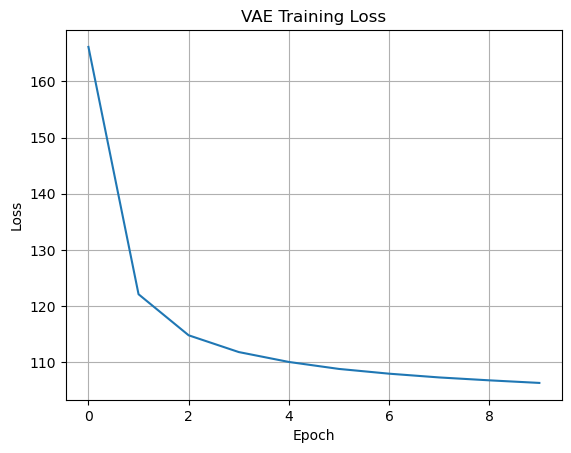

In [22]:
epochs = 10
learning_rate = 1e-3

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

train_losses = []

model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(-1, 784).to(device)
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x)
        loss = loss_function(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss/len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.plot(train_losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



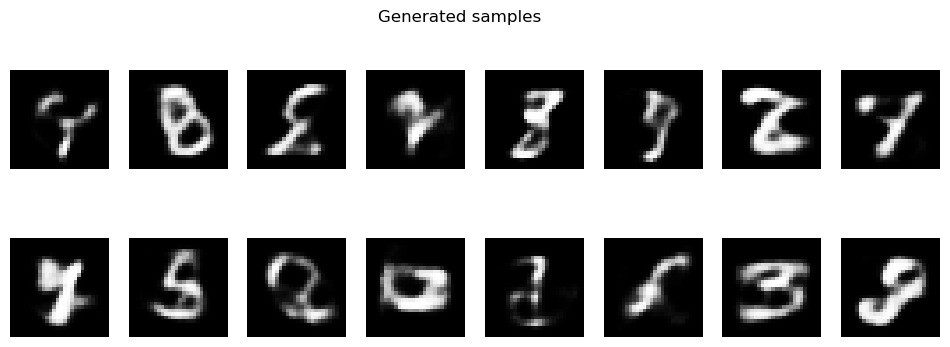

In [24]:
model.eval()

with torch.no_grad():
    z = torch.randn((16,20)).to(device)

    generated = model.decoder(z).cpu()
    generated = generated.view(-1,1,28,28)

# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i][0], cmap='gray')
    ax.axis('off')

plt.suptitle("Generated samples")
plt.show()